# **Main Plot**

/var/folders/rn/4nj37fp17b186g3qlc229y440000gn/T/ipykernel_76410/3446818253.py:94: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_log.groupby(['bin', 'direction'])['bytes'].sum().unstack().fillna(0)


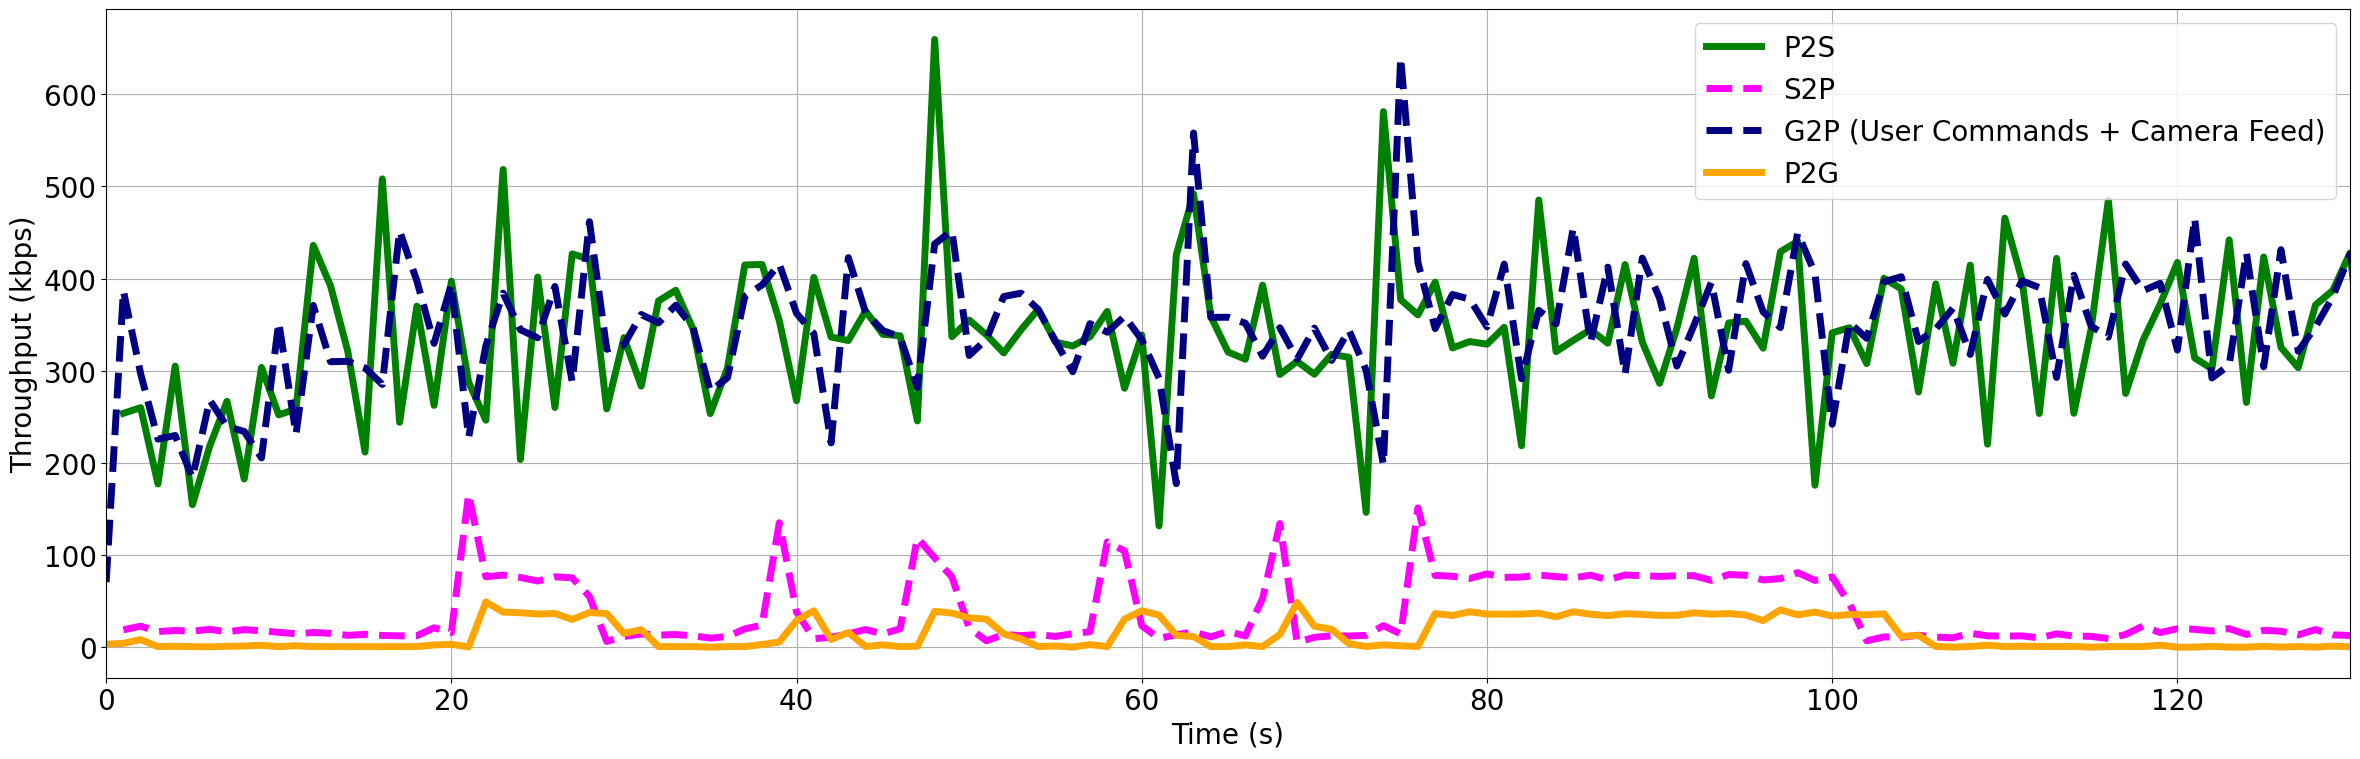

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import datetime
from matplotlib.ticker import FuncFormatter

# Set global font size
plt.rcParams.update({'font.size': 20})

# Initialize the figure and axis
fig, ax = plt.subplots(figsize=(24, 8))

# ---------------------------------------------------------
# PART 1: Read and Plot CSV Data (P2S, S2P)
# ---------------------------------------------------------
try:
    # Read the data from the CSV file
    df_csv = pd.read_csv('PS2_Annotations_test.csv')

    # Convert to kbps
    df_csv['P2S'] = df_csv['P2S'] / 1000
    df_csv['S2P'] = df_csv['S2P'] / 1000

    # Plot P2S with solid line (Green)
    ax.plot(df_csv['Interval start'], df_csv['P2S'], label='P2S', 
            linewidth=5, linestyle='-', color='green')

    # Plot S2P with dashed line (Magenta)
    ax.plot(df_csv['Interval start'], df_csv['S2P'], label='S2P', 
            linewidth=5, linestyle='--', color='magenta')

except FileNotFoundError:
    print("Error: 'PS2_Annotations_test.csv' not found. Skipping P2S/S2P curves.")
except Exception as e:
    print(f"Error processing CSV: {e}")

# ---------------------------------------------------------
# PART 2: Read and Plot Log File Data (P2G, G2P)
# ---------------------------------------------------------
filename = 'G2P_annotations_test.txt'
data = []

try:
    with open(filename, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            # Regex to extract timestamp
            ts_match = re.match(r'(\w+ \d+ \d+:\d+:\d+\.\d+)', line)
            if not ts_match:
                continue
            timestamp_str = ts_match.group(1)

            # Parse timestamp (assuming year 2025)
            try:
                dt = datetime.datetime.strptime(f'2025 {timestamp_str}', '%Y %b %d %H:%M:%S.%f')
            except ValueError:
                continue

            # RFCOMM Parsing
            if 'RFCOMM Send' in line or 'RFCOMM Receive' in line:
                rfcomm_match = re.search(r'RFCOMM (Send|Receive).*UIH (\d+) Bytes Of Data', line)
                if rfcomm_match:
                    action = rfcomm_match.group(1)
                    bytes_count = int(rfcomm_match.group(2))
                    if bytes_count > 0:
                        dir_type = 'data'
                        direction = f"{'sent' if action == 'Send' else 'received'}_{dir_type}"
                        data.append({'time': dt, 'direction': direction, 'bytes': bytes_count})
            
            # L2CAP Parsing
            elif 'L2CAP Send' in line or 'L2CAP Receive' in line:
                l2cap_match = re.search(r'L2CAP (Send|Receive).*Length: 0x[0-9A-F]+ \((\d+)\)', line)
                if l2cap_match:
                    action = l2cap_match.group(1)
                    bytes_count = int(l2cap_match.group(2))
                    if bytes_count > 0:
                        dir_type = 'audio'
                        direction = f"{'sent' if action == 'Send' else 'received'}_{dir_type}"
                        data.append({'time': dt, 'direction': direction, 'bytes': bytes_count})

    # Convert to DataFrame and Process
    df_log = pd.DataFrame(data)

    if not df_log.empty:
        # Calculate relative seconds from the first timestamp
        min_time = df_log['time'].min()
        df_log['time_sec'] = (df_log['time'] - min_time).dt.total_seconds()

        # Create 1-second bins
        max_sec = int(df_log['time_sec'].max()) + 1
        bins = range(0, max_sec + 1)
        df_log['bin'] = pd.cut(df_log['time_sec'], bins=bins, labels=bins[:-1], right=False)

        # Group by bin and direction, sum bytes
        grouped = df_log.groupby(['bin', 'direction'])['bytes'].sum().unstack().fillna(0)

        # Calculate bitrate in kbps
        for col in grouped.columns:
            grouped[col + '_bitrate'] = (grouped[col] * 8) / 1000
        
        # Drop raw bytes columns
        grouped = grouped[[col for col in grouped.columns if '_bitrate' in col]]

        # Rename columns for clarity
        renames = {
            'sent_audio_bitrate': 'sent_description_bitrate',
            'received_audio_bitrate': 'received_voice_bitrate',
            'sent_data_bitrate': 'sent_data_bitrate',
            'received_data_bitrate': 'received_images_bitrate'
        }
        grouped.rename(columns=renames, inplace=True)

        # Plot Styles
        colors = {
            'sent_description_bitrate': 'orange', 
            'received_voice_bitrate': 'navy', 
            'sent_data_bitrate': 'red', 
            'received_images_bitrate': 'brown'
        }
        linestyles = {
            'sent_description_bitrate': '-', 
            'received_voice_bitrate': '--', 
            'sent_data_bitrate': '-.', 
            'received_images_bitrate': ':'
        }
        labels = {
            'sent_description_bitrate': 'P2G',
            'received_voice_bitrate': 'G2P (User Commands + Camera Feed)',
            'sent_data_bitrate': 'Sent Data (kbps)',
            'received_images_bitrate': 'Received Images (kbps)'
        }

        # Plot curves from Log file
        for col in grouped.columns:
            if col in colors:
                ax.plot(grouped.index, grouped[col], linewidth=5, 
                        label=labels.get(col, col), 
                        color=colors[col], 
                        linestyle=linestyles[col])

    else:
        print("No data found in log file.")

except FileNotFoundError:
    print("Error: 'G2P_annotations_test.txt' not found. Skipping P2G/G2P curves.")
except Exception as e:
    print(f"Error processing Log file: {e}")

# ---------------------------------------------------------
# PART 3: Final Formatting and Display
# ---------------------------------------------------------
ax.set_xlabel("Time (s)")
ax.set_ylabel('Throughput (kbps)')
ax.set_xlim(0, 130)


ax.grid(True)
ax.legend(loc='upper right')

# Format y-axis with commas
def fmt(x, pos):
    return '{:,.0f}'.format(x)
ax.yaxis.set_major_formatter(FuncFormatter(fmt))

plt.tight_layout()
plt.savefig("../Plots/Combined_Throughput_Plot.png")
plt.show()